In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
import pandas as pd

sm = pd.read_csv("../data/processed/germany_social_clean.csv")
ec = pd.read_csv("../data/processed/germany_ecommerce_clean.csv")

# 1 Dataset Overview

# 2 Social Media EDA

# 3 Ecommerce EDA

# 4 Demographic Analysis

# 5 Time Trends

# 6 Education Analysis

# 7 Insights

# 1 Dataset Overview

This section examines the overall structure of the cleaned datasets before exploratory analysis.

Objectives:

- Verify dataset dimensions
- Inspect available variables
- Review data types
- Examine missing values
- Understand distribution of observations

Datasets:

1. Germany Social Media Dataset (`germany_social_clean.csv`)
2. Germany Ecommerce Dataset (`germany_ecommerce_clean.csv`)

### Observation

This step verifies the number of rows and columns in both datasets.

Purpose:

- Confirm successful export from cleaning stage
- Check consistency between social media and ecommerce datasets
- Identify possible row loss during filtering

In [104]:
print("SOCIAL MEDIA DATASET")
print(sm.shape)

print("\nECOMMERCE DATASET")
print(ec.shape)

SOCIAL MEDIA DATASET
(384, 24)

ECOMMERCE DATASET
(288, 12)


### Variable Inspection

This section reviews available variables.

Important analytical variables:

- `year`
- `demo_code`
- `education_level`
- `indicator_name`
- `value`

These variables will be used in later demographic and temporal analysis.

In [105]:
sm_indicator_map = {
    'I_IUEM': 'Email Usage',
    'I_IUIF': 'Product Information Search',
    'I_IUNW1': 'Online News Reading',
    'I_IUSNET': 'Social Media Participation'
}

sm['indicator_name'] = sm['indicator_code'].map(sm_indicator_map)

In [106]:
sm['indicator_name'].value_counts()

indicator_name
Email Usage                   96
Product Information Search    96
Online News Reading           96
Social Media Participation    96
Name: count, dtype: int64

In [107]:
#Check available variables.
sm.columns.tolist()

['STRUCTURE',
 'STRUCTURE_ID',
 'STRUCTURE_NAME',
 'freq',
 'Time frequency',
 'indicator_code',
 'indicator',
 'unit',
 'Unit of measure',
 'demo_code',
 'demographic',
 'country',
 'Geopolitical entity (reporting)',
 'year',
 'Time',
 'value',
 'Observation value',
 'obs_flag',
 'Observation status (Flag) V2 structure',
 'conf_status',
 'Confidentiality status (flag)',
 'missing_flag',
 'demo_type',
 'education_level',
 'indicator_name']

In [108]:
ec.columns.tolist()

['demo_code',
 'demographic',
 'demo_type',
 'education_level',
 'indicator_code',
 'indicator_name',
 'country',
 'year',
 'unit',
 'value',
 'obs_flag',
 'missing_flag']

### Data Types Review

This step checks variable formats.

Expected structure:

- Numeric variables:
    - value
    - year

- Categorical variables:
    - demographic
    - education_level
    - indicator_name

This ensures variables are suitable for aggregation and visualization.

In [109]:
#Data types
sm.info()

<class 'pandas.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 25 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               384 non-null    str    
 1   STRUCTURE_ID                            384 non-null    str    
 2   STRUCTURE_NAME                          384 non-null    str    
 3   freq                                    384 non-null    str    
 4   Time frequency                          384 non-null    str    
 5   indicator_code                          384 non-null    str    
 6   indicator                               384 non-null    str    
 7   unit                                    384 non-null    str    
 8   Unit of measure                         384 non-null    str    
 9   demo_code                               384 non-null    str    
 10  demographic                             384 non-null    str    
 11  coun

In [110]:
ec.info()

<class 'pandas.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   demo_code        288 non-null    str    
 1   demographic      288 non-null    str    
 2   demo_type        180 non-null    str    
 3   education_level  288 non-null    str    
 4   indicator_code   288 non-null    str    
 5   indicator_name   288 non-null    str    
 6   country          288 non-null    str    
 7   year             288 non-null    int64  
 8   unit             288 non-null    str    
 9   value            288 non-null    float64
 10  obs_flag         45 non-null     str    
 11  missing_flag     180 non-null    object 
dtypes: float64(1), int64(1), object(1), str(9)
memory usage: 27.1+ KB


### Missing Value Assessment

Purpose:

- Detect incomplete observations
- Verify education labels
- Check indicator availability

Special attention:

The project previously identified non-education segments labelled as:

`Not Education Segment`

These values are intentional and not considered missing data.

### Missing Value Observation

Most analytical variables contain no missing values.

No missing values were found in:

- value
- year
- education_level
- indicator_name
- demographic

Missing values appear mainly in metadata columns:

- obs_flag
- demo_type
- missing_flag

These fields contain Eurostat annotations and do not affect analysis.

In [111]:
#missing value
sm.isnull().sum().sort_values(
ascending=False
)


Confidentiality status (flag)             384
conf_status                               384
Observation value                         384
Time                                      384
Observation status (Flag) V2 structure    304
obs_flag                                  304
STRUCTURE                                   0
year                                        0
education_level                             0
demo_type                                   0
missing_flag                                0
value                                       0
Geopolitical entity (reporting)             0
STRUCTURE_ID                                0
country                                     0
demographic                                 0
demo_code                                   0
Unit of measure                             0
unit                                        0
indicator                                   0
indicator_code                              0
Time frequency                    

In [112]:
ec.isnull().sum().sort_values(
ascending=False
)

obs_flag           243
demo_type          108
missing_flag       108
demo_code            0
demographic          0
education_level      0
indicator_code       0
indicator_name       0
country              0
year                 0
unit                 0
value                0
dtype: int64

### Descriptive Statistics

This section summarizes numerical variables.

Key metrics:

- Mean
- Standard deviation
- Minimum
- Maximum

Focus variable:

`value`

This variable represents percentage indicators reported by Eurostat.

In [113]:
#summary statistics
sm.describe(include='all')



,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,indicator_code,indicator,unit,Unit of measure,demo_code,...,value,Observation value,obs_flag,Observation status (Flag) V2 structure,conf_status,Confidentiality status (flag),missing_flag,demo_type,education_level,indicator_name
count,384,384,384,384,384,384,384,384,384,384,...,384.000000,0.0,80,80,0.0,0.0,384,384,384,384
unique,1,1,1,1,1,4,4,1,1,16,...,NaN,NaN,2,2,NaN,NaN,1,2,4,4
top,dataflow,ESTAT:ISOC_CI_AC_I(1.0),Individuals - internet activities,A,Annual,I_IUEM,Internet use: sending/receiving e-mails,PC_IND,Percentage of individuals,F_Y16_74,...,NaN,NaN,b,break in time series,NaN,NaN,False,Age,Not Education Segment,Email Usage
freq,384,384,384,384,384,96,96,384,384,24,...,NaN,NaN,64,64,NaN,NaN,384,336,168,96
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,66.055703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.139600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.170000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,51.147500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,66.440000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,83.517500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
ec.describe(include='all')

,demo_code,demographic,demo_type,education_level,indicator_code,indicator_name,country,year,unit,value,obs_flag,missing_flag
count,288,288,180,288,288,288,288,288.000000,288,288.000000,45,180
unique,15,15,3,4,3,3,1,NaN,1,NaN,1,1
top,Y16_24HI,Individuals aged 16-24 with high formal education,Age,Not Education Segment,I_BF_3-5,Moderate Purchase Frequency (3–5 purchases),DE,NaN,PC_IND,NaN,b,False
freq,24,24,144,180,96,96,288,NaN,288,NaN,45,180
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.250000,NaN,15.867292,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.923629,NaN,8.102863,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,1.210000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.750000,NaN,9.515000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,NaN,14.420000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.500000,NaN,22.040000,NaN,NaN


## Section 2 — Temporal Coverage

# 2 Temporal Coverage

Check available years and yearly balance.

In [115]:
sorted(
sm['year'].unique()
)

[np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025)]

In [116]:
sorted(
ec['year'].unique()
)

[np.int64(2020), np.int64(2021), np.int64(2023), np.int64(2025)]

In [117]:
#Year distribution
sm['year'].value_counts().sort_index()

year
2020    64
2021    64
2022    64
2023    64
2024    64
2025    64
Name: count, dtype: int64

In [118]:
ec['year'].value_counts().sort_index()

year
2020    72
2021    72
2023    72
2025    72
Name: count, dtype: int64

## Section 3 — Education Coverage

# Observation:

The education segment counts are not equal between the social media and e-commerce datasets. This is expected because the datasets contain different indicators and different year availability. Social media has broader temporal and indicator coverage, while e-commerce purchase-frequency indicators are available for fewer years. Therefore, row counts should not be directly compared across datasets.

### Education segments

In [119]:
sm['education_level'].value_counts()

education_level
Not Education Segment    168
High Education            72
Low Education             72
Medium Education          72
Name: count, dtype: int64

In [120]:
ec[
'education_level'
].value_counts()

education_level
Not Education Segment    180
High Education            36
Low Education             36
Medium Education          36
Name: count, dtype: int64

In [121]:
sm.groupby(
['year','education_level']
).size()

year  education_level      
2020  High Education           12
      Low Education            12
      Medium Education         12
      Not Education Segment    28
2021  High Education           12
      Low Education            12
      Medium Education         12
      Not Education Segment    28
2022  High Education           12
      Low Education            12
      Medium Education         12
      Not Education Segment    28
2023  High Education           12
      Low Education            12
      Medium Education         12
      Not Education Segment    28
2024  High Education           12
      Low Education            12
      Medium Education         12
      Not Education Segment    28
2025  High Education           12
      Low Education            12
      Medium Education         12
      Not Education Segment    28
dtype: int64

In [122]:
ec.groupby(
['year','education_level']
).size()

year  education_level      
2020  High Education            9
      Low Education             9
      Medium Education          9
      Not Education Segment    45
2021  High Education            9
      Low Education             9
      Medium Education          9
      Not Education Segment    45
2023  High Education            9
      Low Education             9
      Medium Education          9
      Not Education Segment    45
2025  High Education            9
      Low Education             9
      Medium Education          9
      Not Education Segment    45
dtype: int64

## Section 4 — Indicator Coverage

In [151]:
sm[
'indicator_name'
].value_counts()

indicator_name
Email Usage                   96
Product Information Search    96
Online News Reading           96
Social Media Participation    96
Name: count, dtype: int64

In [152]:
ec[
'indicator_name'
].value_counts()

indicator_name
Moderate Purchase Frequency (3–5 purchases)     96
High Purchase Frequency (6–10 purchases)        96
Very High Purchase Frequency (10+ purchases)    96
Name: count, dtype: int64

## Section 5 — Social Media Trend Over Time

# Social Media Trend Analysis

Objective:

Analyze how social media usage changed in Germany from 2020–2025.

This section evaluates yearly trends using average indicator values.

In [125]:
sm_year = sm.groupby(
'year'
)['value'].mean().reset_index()

sm_year

,year,value
0,2020,75.136094
1,2021,60.888750
2,2022,61.270000
3,2023,57.106563
4,2024,70.291094
5,2025,71.641719


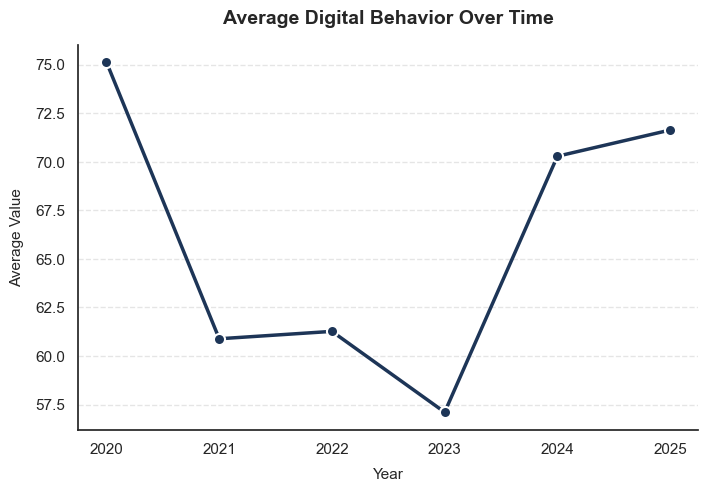

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, minimalist background style (removes the default grey/harsh lines)
sns.set_theme(style="white")

# 2. Initialize the figure size
plt.figure(figsize=(8, 5))

# 3. Plot the line with custom colors, thickness, and larger markers
sns.lineplot(
    data=sm_year,
    x='year',
    y='value',
    marker='o',
    markersize=8,          # Makes the data points more distinct
    linewidth=2.5,         # Thickens the line for better readability
    color='#1d3557',       # Swaps default blue for a sleek navy hex code
    markerfacecolor='#1d3557',
    markeredgecolor='w',   # Gives markers a clean white border
    markeredgewidth=1.5
)

# 4. Add subtle horizontal gridlines to help guide the eye across Y-values
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')

# 5. Add styled titles and labels
plt.title('Average Digital Behavior Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11, labelpad=8)
plt.ylabel('Average Value', fontsize=11, labelpad=8)

# 6. Crucial step: Remove the top and right black border boxes (spines)
sns.despine()

# 7. Render the final clean visualization
plt.show()

### Observation

This chart shows the average level of digital engagement in Germany across the observed years.

The values represent a combined average of multiple digital behavior indicators, including email usage, internet usage, product information search, online news reading, and social media participation.

Overall digital engagement remains relatively stable over time, although some fluctuations are visible between years.

Because multiple indicators are averaged together, this chart should be interpreted as a broad digital engagement trend rather than a specific activity trend.

## Section 6 — Ecommerce Trend

# Ecommerce Trend Analysis

Objective:

Examine purchase behavior trends across years.

In [127]:
ec_year_indicator = (
    ec.groupby(['year', 'indicator_name'])['value']
      .mean()
      .reset_index()
)

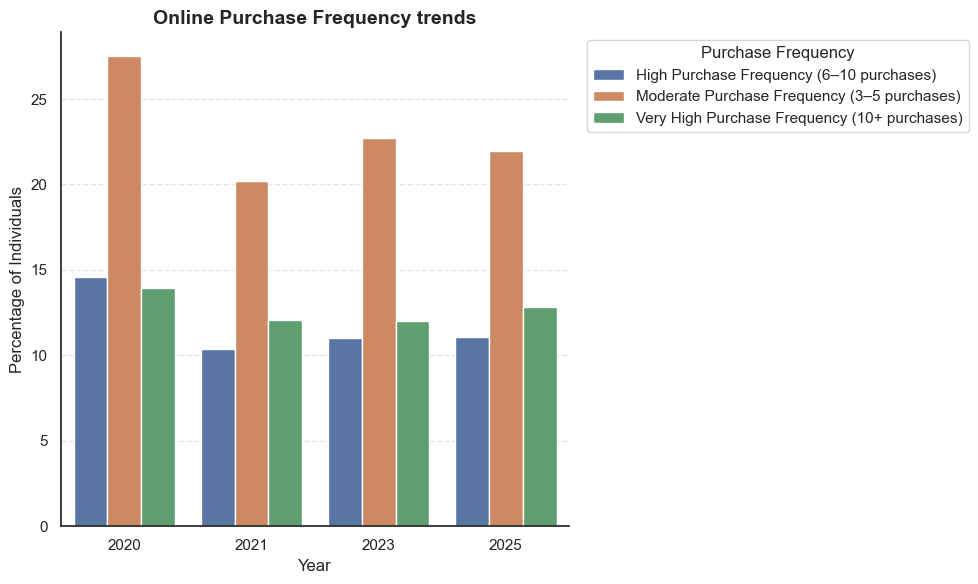

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=ec_year_indicator,
    x='year',
    y='value',
    hue='indicator_name'
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.title(
    'Online Purchase Frequency trends',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Percentage of Individuals')

plt.legend(
    title='Purchase Frequency',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sns.despine()

plt.tight_layout()
plt.show()

### Observation


Instead of averaging all ecommerce categories together, this visualization displays each purchase-frequency group separately.

This makes it easier to understand how online purchasing behavior is distributed across the population and how those patterns change over time.

The Moderate Purchase Frequency group (3–5 purchases) consistently represents the largest segment of online shoppers across all observed years.

## Section 7 — Education comparison

# Education Level Comparison

Objective:

Compare digital behavior among education groups.

In [129]:
sm_edu = sm.groupby(
'education_level'
)['value'].mean().reset_index()

sm_edu

,education_level,value
0,High Education,78.002222
1,Low Education,53.100278
2,Medium Education,69.026944
3,Not Education Segment,65.214702


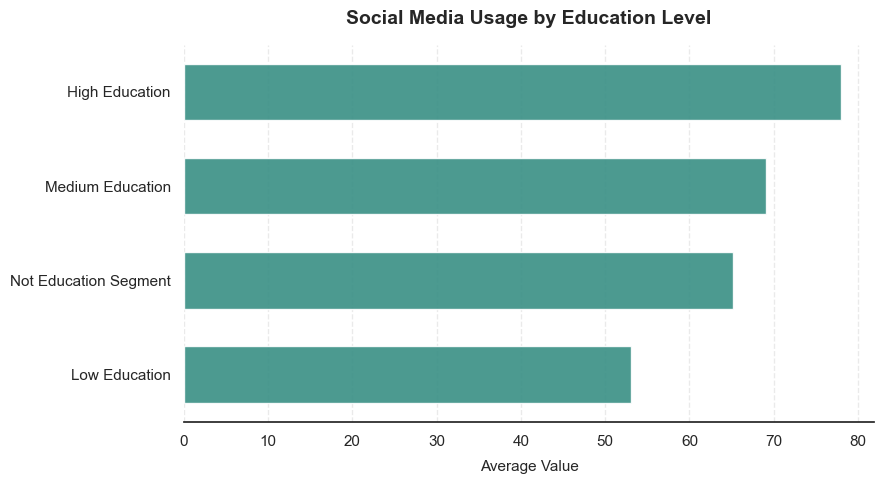

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean minimalist style
sns.set_theme(style="white")
plt.figure(figsize=(9, 5))

# Sort the dataframe by value first so the longest/highest bars sit nicely at the top
df_sorted = sm_edu.sort_values(by='value', ascending=False)

# Create a horizontal bar plot (swap x and y)
sns.barplot(
    data=df_sorted,
    x='value',
    y='education_level',
    color='#2a9d8f',       # Clean, modern teal hex color
    alpha=0.9,
    width=0.6              # Gives breathing room between bars
)

# Soft vertical grid lines to guide the eye across values
plt.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')

# Beautiful Typography
plt.title('Social Media Usage by Education Level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Value', fontsize=11, labelpad=8)
plt.ylabel('', fontsize=11) # Removing 'education_level' completely since the categories speak for themselves

# Clean up layout and drop outer frames
sns.despine(left=True, bottom=False) # Keep bottom line, remove left spine for a floating look
plt.tight_layout()
plt.show()

### Observation

Digital engagement varies across education groups.

The chart helps identify whether education level is associated with differences in online activity.

Higher values indicate stronger participation in digital activities such as internet usage, email usage, social media participation, and online information search.

In [131]:
ec_year_indicator = (
    ec.groupby(
        ['year', 'indicator_name']
    )['value']
    .mean()
    .reset_index()
)

ec_year_indicator.head()

,year,indicator_name,value
0,2020,High Purchase Frequency (6–10 purchases),14.613333
1,2020,Moderate Purchase Frequency (3–5 purchases),27.527917
2,2020,Very High Purchase Frequency (10+ purchases),13.933750
3,2021,High Purchase Frequency (6–10 purchases),10.390417
4,2021,Moderate Purchase Frequency (3–5 purchases),20.198333


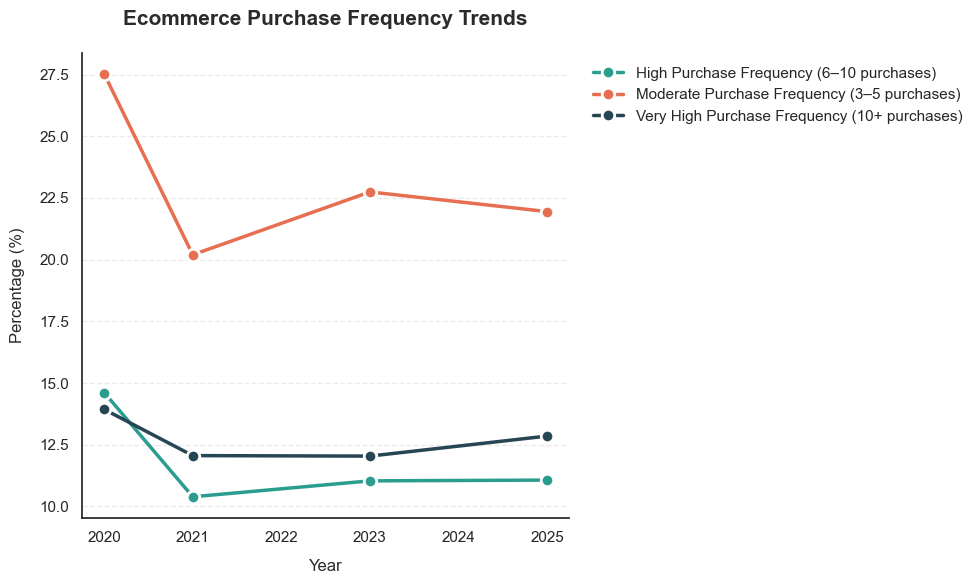

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Start with a beautiful crisp theme
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# 2. Define a premium color palette (e.g., varying rich teals/corals or a custom palette)
# This replaces the harsh default contrast with something professionally styled
custom_palette = ["#2a9d8f", "#e76f51", "#264653"]

# 3. Plot the lines
sns.lineplot(
    data=ec_year_indicator,
    x='year',
    y='value',
    hue='indicator_name',
    palette=custom_palette,
    marker='o',
    markersize=9,           # Larger, punchier markers
    linewidth=2.5,          # Thicker, prominent lines
    markeredgecolor='w',    # White boundary rings to make markers pop
    markeredgewidth=2
)

# 4. Background enhancements
plt.grid(axis='y', linestyle='--', alpha=0.4, color='#cccccc')

# 5. Professional Typography & Label styling
plt.title('Ecommerce Purchase Frequency Trends', fontsize=15, fontweight='bold', pad=20, color='#2b2b2b')
plt.xlabel('Year', fontsize=12, labelpad=10, color='#2b2b2b')
plt.ylabel('Percentage (%)', fontsize=12, labelpad=10, color='#2b2b2b')

# Clean up X-axis to explicitly account for integer year increments
plt.xticks(range(2020, 2026))

# 6. Master the Legend
# We move it slightly outside the plotting box, remove the rigid frame, and clear the ugly 'indicator_name' header
plt.legend(
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    frameon=False, 
    fontsize=11,
    title=None  # Strips away 'indicator_name' header text
)

# 7. Strip unnecessary border boxes
sns.despine()

# Ensure layout accounts nicely for the legend on the right hand side
plt.tight_layout()
plt.show()

### Observation

This chart compares online purchasing activity across education levels.

Differences between groups may indicate that education level influences ecommerce participation.

Groups with higher values report more frequent online purchasing behavior.

## Section 8 — Indicator comparison

In [133]:
sm_indicator = sm.groupby(
'indicator_name'
)['value'].mean().reset_index()

sm_indicator

,indicator_name,value
0,Email Usage,82.490104
1,Online News Reading,60.587083
2,Product Information Search,66.020625
3,Social Media Participation,55.125000


In [134]:
sm_year_indicator = sm.groupby(
    ['year','indicator_name']
)['value'].mean().reset_index()

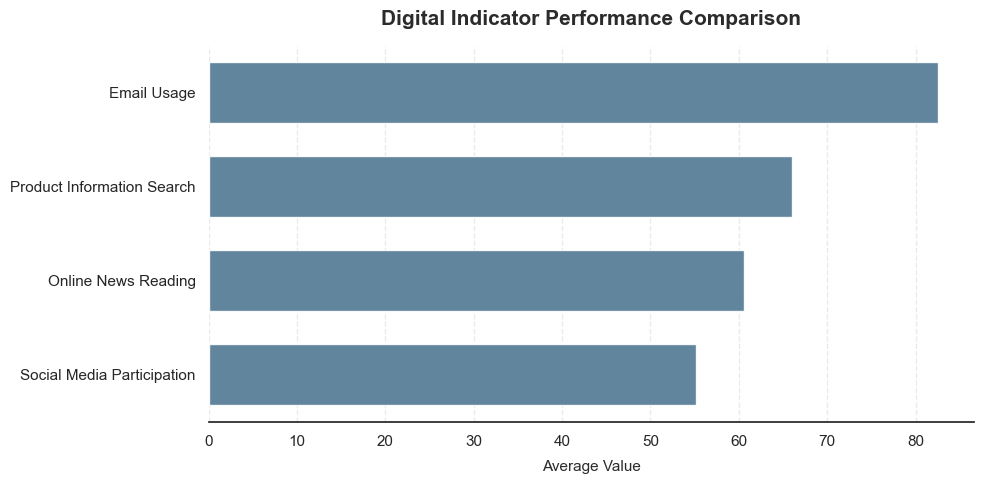

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Apply a minimalist white theme
sns.set_theme(style="white")
plt.figure(figsize=(10, 5))

# 2. CRITICAL: Sort the data descending by value so the bars cascade beautifully
df_sorted = sm_indicator.sort_values(by='value', ascending=False)

# 3. Create a horizontal bar chart by swapping x and y
sns.barplot(
    data=df_sorted,
    x='value',
    y='indicator_name',
    color='#457b9d',       # Clean, modern slate blue hex
    alpha=0.9,
    width=0.65             # Add slight spacing between bars
)

# 4. Add subtle background vertical grids to guide value reading
plt.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')

# 5. Clean, descriptive titles and labels
plt.title('Digital Indicator Performance Comparison', fontsize=15, fontweight='bold', pad=15, color='#2b2b2b')
plt.xlabel('Average Value', fontsize=11, labelpad=8, color='#2b2b2b')
plt.ylabel('')  # Drop the redundant 'indicator_name' label entirely to save space

# 6. Keep the baseline but drop the top, right, and left frames for a floating effect
sns.despine(left=True, bottom=False)

# Ensure the long text labels fit nicely on the left edge without clipping
plt.tight_layout()
plt.show()

### Observation

Email Usage shows the highest average participation among the digital behavior indicators.

Internet Usage, Product Information Search, Online News Reading, and Social Media Participation show lower average values.

Product Information Search is particularly important from a digital marketing perspective because it reflects consumers using online channels to research products before making purchasing decisions.

In [136]:
sm[['indicator_code','indicator_name']].drop_duplicates().sort_values('indicator_code')

,indicator_code,indicator_name
0,I_IUEM,Email Usage
96,I_IUIF,Product Information Search
192,I_IUNW1,Online News Reading
288,I_IUSNET,Social Media Participation


In [137]:
sm.loc[
    sm['indicator_code'] == 'I_IUPH1',
    'indicator_name'
] = 'Internet Usage'

In [138]:
sm_indicator = sm.groupby(
    'indicator_name'
)['value'].mean().reset_index()

In [139]:
sm_indicator

,indicator_name,value
0,Email Usage,82.490104
1,Online News Reading,60.587083
2,Product Information Search,66.020625
3,Social Media Participation,55.125000


In [140]:
sm[['indicator_code','indicator_name']].drop_duplicates().sort_values('indicator_code')

,indicator_code,indicator_name
0,I_IUEM,Email Usage
96,I_IUIF,Product Information Search
192,I_IUNW1,Online News Reading
288,I_IUSNET,Social Media Participation


In [141]:
ec_indicator = ec.groupby(
'indicator_name'
)['value'].mean().reset_index()

ec_indicator

,indicator_name,value
0,High Purchase Frequency (6–10 purchases),11.776354
1,Moderate Purchase Frequency (3–5 purchases),23.105000
2,Very High Purchase Frequency (10+ purchases),12.720521


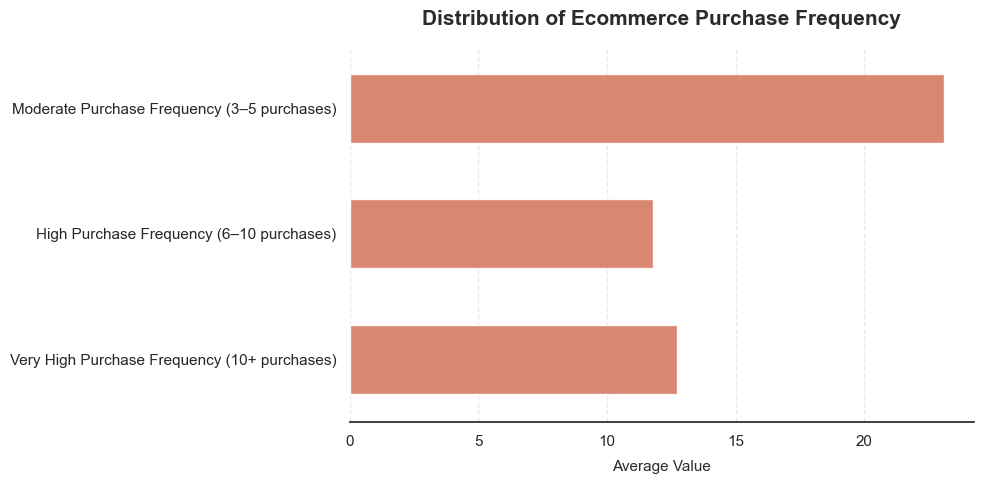

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean background style
sns.set_theme(style="white")
plt.figure(figsize=(10, 5))

# 2. CRITICAL: Manually force the logical, sequential order of intensity
logical_order = [
    'Moderate Purchase Frequency (3–5 purchases)',
    'High Purchase Frequency (6–10 purchases)',
    'Very High Purchase Frequency (10+ purchases)'
]

# 3. Create a horizontal bar chart
sns.barplot(
    data=ec_indicator,
    x='value',
    y='indicator_name',
    order=logical_order,   # Enforces the natural sequential order
    color='#e76f51',       # Warm coral hex code
    alpha=0.9,
    width=0.55             # Adds balanced breathing room between bars
)

# 4. Subtle scale gridlines
plt.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')

# 5. Clean, professional text hierarchy
plt.title('Distribution of Ecommerce Purchase Frequency', fontsize=15, fontweight='bold', pad=15, color='#2b2b2b')
plt.xlabel('Average Value', fontsize=11, labelpad=8, color='#2b2b2b')
plt.ylabel('')  # Drop the redundant 'indicator_name' label entirely

# 6. Remove harsh borders
sns.despine(left=True, bottom=False)

# Auto-adjust so your long category labels don't get cut off on the left margin
plt.tight_layout()
plt.show()

### Observation

The Moderate Purchase Frequency category (3–5 purchases) represents the largest group of online shoppers.

The High Purchase Frequency (6–10 purchases) and Very High Purchase Frequency (10+ purchases) groups account for smaller shares of the population.

This indicates that moderate ecommerce participation is more common than intensive online purchasing behavior.

## Section 9 — Distribution

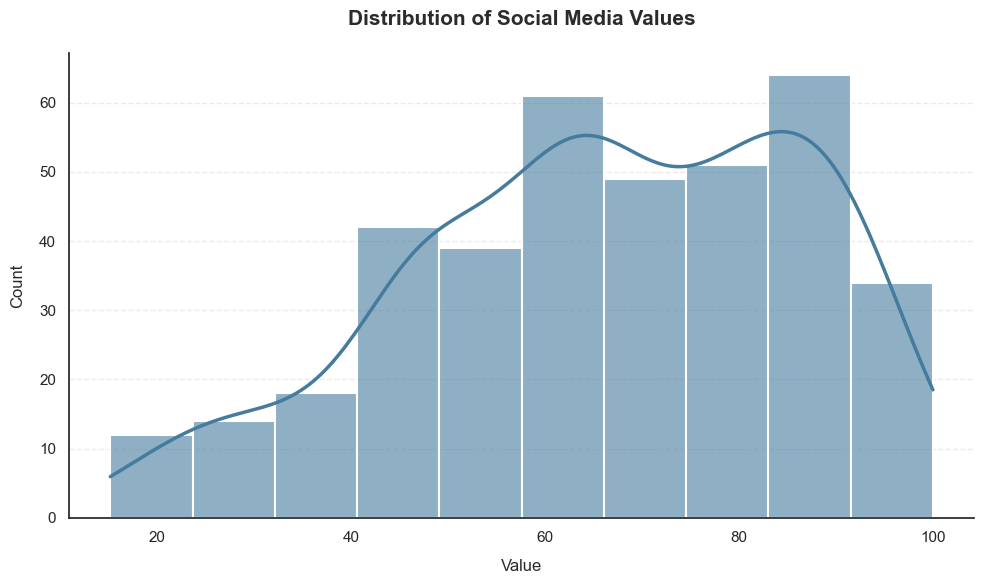

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean theme
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# 2. Plot the histogram with a smooth KDE curve overlay
sns.histplot(
    data=sm,  # Social media dataframe
    x='value',
    kde=True,               # Adds the beautiful smooth distribution line
    color='#457b9d',        # Clean slate blue color
    alpha=0.6,              # Soft transparency for the bars
    edgecolor='w',          # Crisp white edges instead of heavy black lines
    linewidth=1.5,
    line_kws={'linewidth': 2.5, 'color': '#1d3557'} # Custom styles for the trendline
)

# 3. Add faint horizontal gridlines
plt.grid(axis='y', linestyle='--', alpha=0.4, color='#cccccc')

# 4. Premium Typography & Labels
plt.title('Distribution of Social Media Values', fontsize=15, fontweight='bold', pad=20, color='#2b2b2b')
plt.xlabel('Value', fontsize=12, labelpad=10, color='#2b2b2b')
plt.ylabel('Count', fontsize=12, labelpad=10, color='#2b2b2b')

# 5. Clean layout frames
sns.despine()

plt.tight_layout()
plt.show()

### Observation

This histogram shows how digital engagement values are distributed across observations.

Most values appear concentrated within a specific range, suggesting relatively consistent digital behavior across the population.

The distribution also helps identify potential outliers and unusually high or low observations.

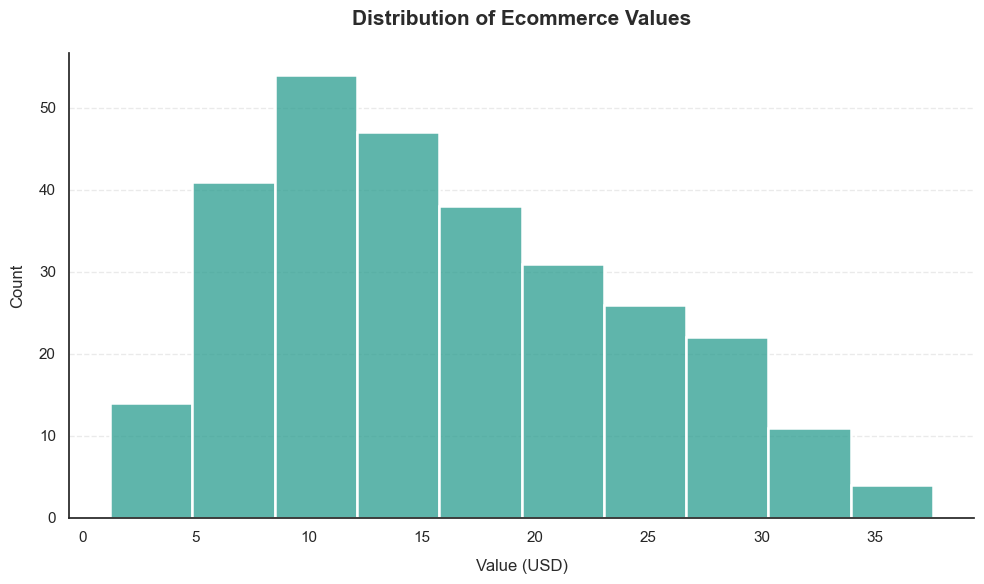

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize a clean, presentation-ready theme
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# 2. Plot the histogram with soft borders and light transparency
sns.histplot(
    data=ec,          # Ecommerce dataframe
    x='value',
    color='#2a9d8f',    # A vibrant, premium teal-green palette color
    alpha=0.75,         # Softens the fill color slightly
    edgecolor='w',      # Crisp white edges create elegant negative space gaps
    linewidth=1.8       # Clean separation thickness
)

# 3. Add soft, faint horizontal reference lines
plt.grid(axis='y', linestyle='--', alpha=0.4, color='#cccccc')

# 4. Premium Typography and Labels
plt.title('Distribution of Ecommerce Values', fontsize=15, fontweight='bold', pad=20, color='#2b2b2b')
plt.xlabel('Value (USD)', fontsize=12, labelpad=10, color='#2b2b2b')
plt.ylabel('Count', fontsize=12, labelpad=10, color='#2b2b2b')

# 5. Remove the heavy top and right border boxes
sns.despine()

# Ensure layout fits beautifully without margins clipping labels
plt.tight_layout()
plt.show()

### Observation

This histogram displays the distribution of ecommerce participation values.

Most observations fall within lower to moderate ranges, while higher purchase-frequency values are less common.

This supports previous findings that moderate online purchasing behavior is more widespread than very high purchasing frequency.

In [154]:
sm[['indicator_code','indicator_name']].drop_duplicates()

,indicator_code,indicator_name
0,I_IUEM,Email Usage
96,I_IUIF,Product Information Search
192,I_IUNW1,Online News Reading
288,I_IUSNET,Social Media Participation


In [155]:
ec[['indicator_code','indicator_name']].drop_duplicates()

,indicator_code,indicator_name
0,I_BF_3-5,Moderate Purchase Frequency (3–5 purchases)
4,I_BF_6-10,High Purchase Frequency (6–10 purchases)
8,I_BF_GT10,Very High Purchase Frequency (10+ purchases)


In [147]:
sm.shape

(384, 25)

In [153]:
'indicator_name' in sm.columns

True